# * Mobile Devices

In [21]:
import configparser
import datetime as dt
import pandas as pd
import numpy as np
import xlrd
import oracledb
import re
import missingno as msno
from ydata_profiling import ProfileReport
from scipy.stats import skew

config = configparser.ConfigParser()
config.read('../../my_config.ini')
config.sections()

curr_dt = dt.datetime.now().date()
str_curr_dt = curr_dt.strftime('%Y%m%d')

In [2]:
''' Input parameter '''

# op_dir = 'C:/Ruz/MyProject/Code/Jupyter/data/Warroom/Mobile Device/output'
op_dir = '../../data/Warroom/Mobile Device/output'
op_file = f'mobile_device_{str_curr_dt}'

print(f'\nParameter input...\n')
print(f'   -> op_dir: {op_dir}')
print(f'   -> op_file: {op_file}')


Parameter input...

   -> op_dir: ../../data/Warroom/Mobile Device/output
   -> op_file: mobile_device_20260313


### Step 1 : Import Data Source

In [3]:
''' Rawdata '''

src_file = 'C:/Ruz/TrueCorp/VC 2026/Warroom/Mobile Devices/RAW_MSISDN_DEVICE_NANOCLUSTER-MKS_ARPU.csv'
src_df = pd.read_csv(src_file)

print(f'\nsrc_df : {src_df.shape[0]} rows, {src_df.shape[1]} columns')
src_df.tail(3)


src_df : 8045317 rows, 32 columns


,CUSTOMER,MSISDN,ACCOUNT_TYPE,ACTIVE_IND,AOU_DEVICE,ARPU_RANGE,CCAATT,SITENAME,REGION,PROVINCE_EN,...,FLAG_DEVICE_IOS-BELOW-IPHONE11,FLAG_4Yearold-luanch_Device,qk16_cen_latitude,qk16_cen_longitude,NN_ID,CLSTR_GRP,TRUEDTAC_MKS,HH,POP,ARPU
8045314,D,66633299855,PREPAID,Y,>18Months,0-99,700701.0,RCB1001,Central-West,Ratchaburi,...,N,N,13.696693,99.846497,700713-001,1,39.96,2105,5979,34.9985
8045315,D,66804381244,PREPAID,Y,>18Months,100-199,570906.0,CRI0517,North,Chiang Rai,...,N,N,20.434734,99.879456,570906-001,6,62.01,15735,34560,185.4206
8045316,D,66629693836,PREPAID,Y,>18Months,300-399,900311.0,SKA0115,South,Songkhla,...,N,Y,6.880073,100.719910,900311-001,4,42.24,1549,5836,329.3637


### Step 2 : Scan Data

In [4]:
# ดูภาพรวมของประเภทข้อมูลและ Memory
src_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8045317 entries, 0 to 8045316
Data columns (total 32 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   CUSTOMER                        object 
 1   MSISDN                          int64  
 2   ACCOUNT_TYPE                    object 
 3   ACTIVE_IND                      object 
 4   AOU_DEVICE                      object 
 5   ARPU_RANGE                      object 
 6   CCAATT                          float64
 7   SITENAME                        object 
 8   REGION                          object 
 9   PROVINCE_EN                     object 
 10  DISTRICT_EN                     object 
 11  SUB_DISTRICT_EN                 object 
 12  IMEI_TAC                        int64  
 13  mkt_brand_name                  object 
 14  handset_model                   object 
 15  mkt_model_name                  object 
 16  DVC_OS                          object 
 17  DVC_TYPE                   

In [8]:
# ดูขนาดของข้อมูล (Row, Column)
src_df.shape

(8045317, 32)

In [10]:
# เช็กค่าว่างรายคอลัมน์
missing_count = src_df.isnull().sum()
missing_count

CUSTOMER                               0
MSISDN                                 0
ACCOUNT_TYPE                           0
ACTIVE_IND                             0
AOU_DEVICE                             0
ARPU_RANGE                             0
CCAATT                              1929
SITENAME                               0
REGION                              1929
PROVINCE_EN                         1929
DISTRICT_EN                         1929
SUB_DISTRICT_EN                     1929
IMEI_TAC                               0
mkt_brand_name                         0
handset_model                         23
mkt_model_name                         0
DVC_OS                                 0
DVC_TYPE                               0
DATA_GB_PER_MONTH                      0
AOU_SIM_RANGE                          0
FLAG_DVC-CONTRACT_EXP3MONTHS           0
FLAG_DEVICE_BELOW5G                    0
FLAG_DEVICE_IOS-BELOW-IPHONE11         0
FLAG_4Yearold-luanch_Device            0
qk16_cen_latitud

<Axes: >

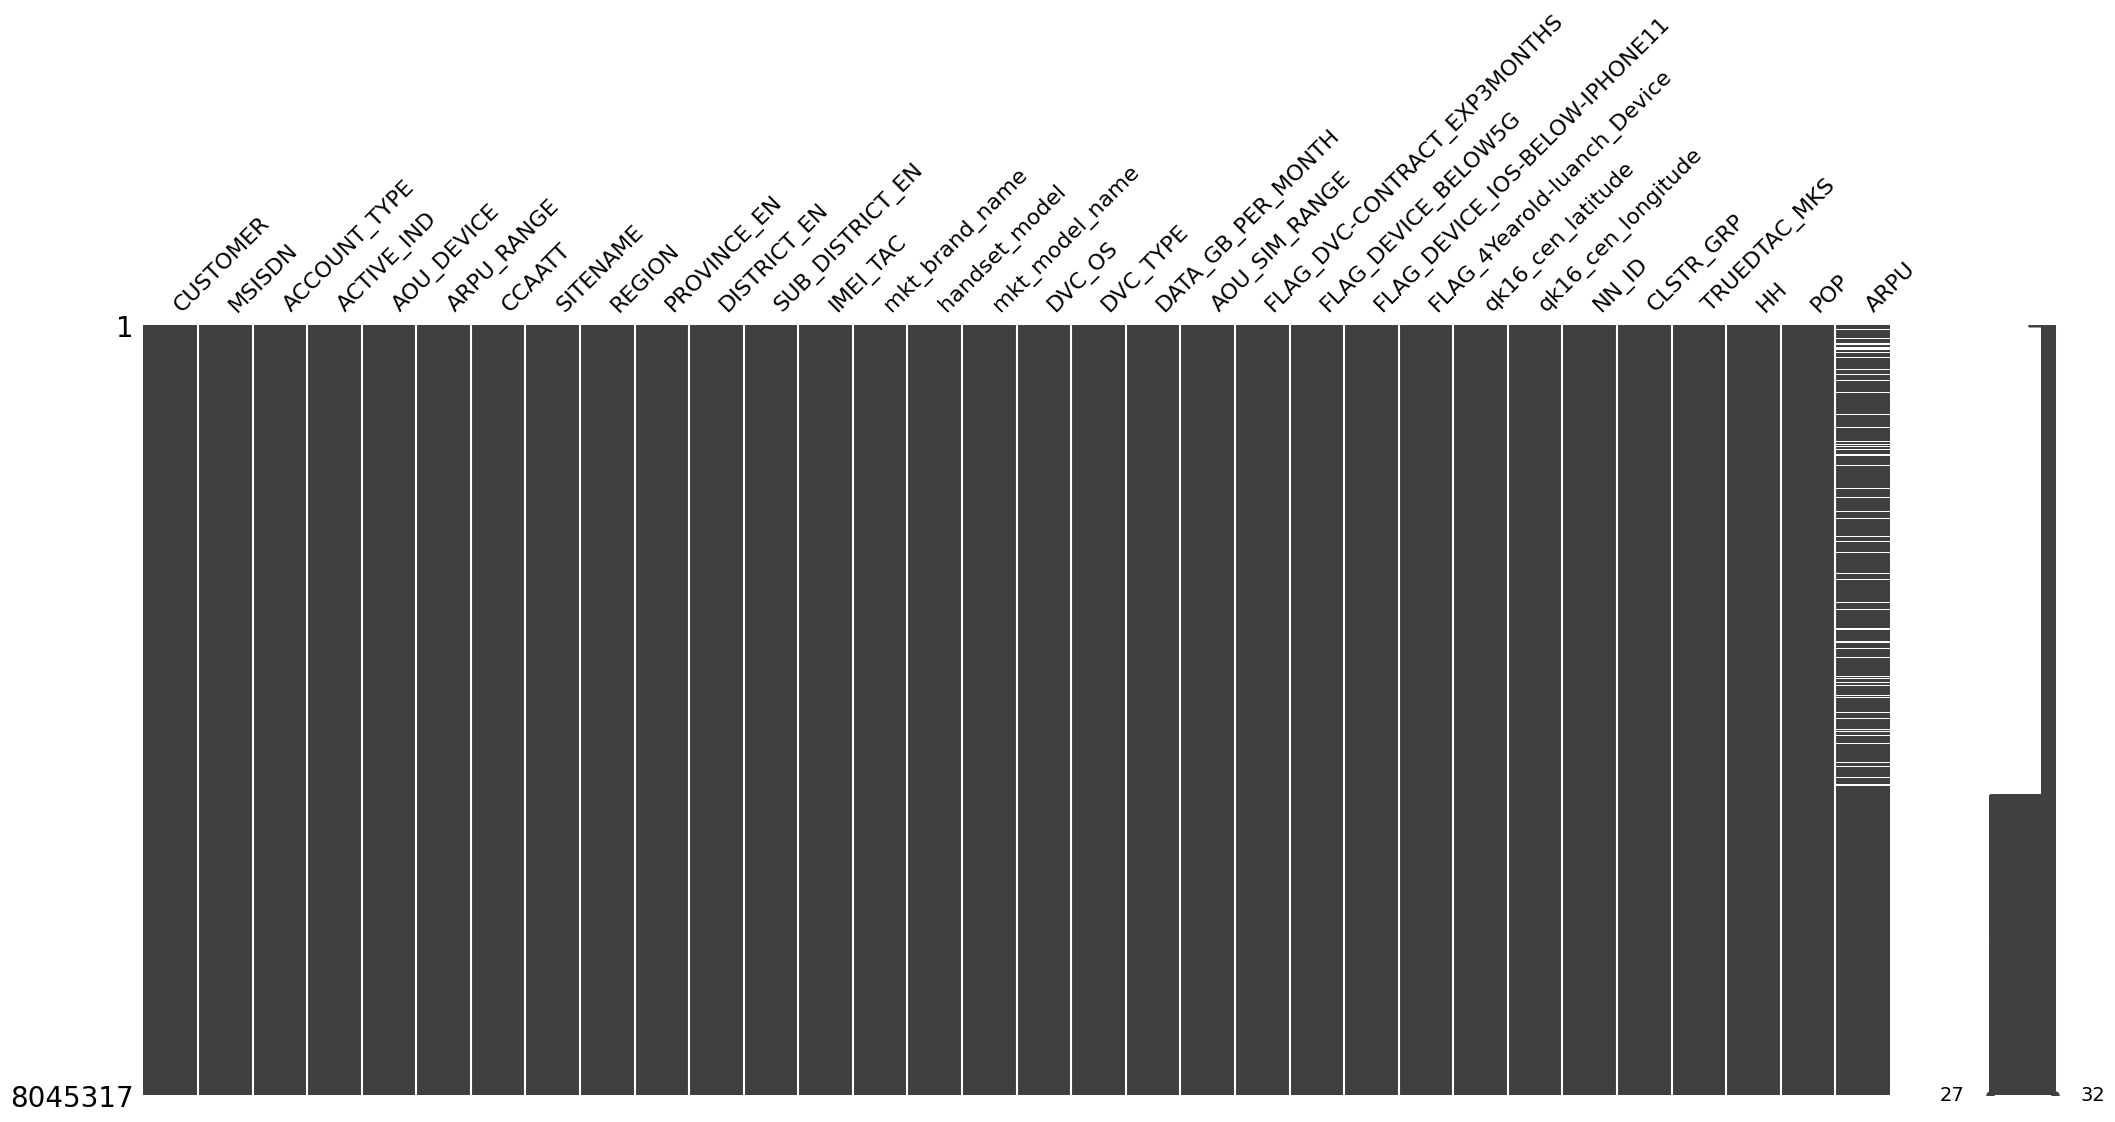

In [12]:
# ใช้ Library 'missingno' เพื่อดู Pattern การหายไปของข้อมูล
msno.matrix(src_df)

In [13]:
src_df.describe()

,MSISDN,CCAATT,IMEI_TAC,DATA_GB_PER_MONTH,FLAG_DVC-CONTRACT_EXP3MONTHS,qk16_cen_latitude,qk16_cen_longitude,CLSTR_GRP,TRUEDTAC_MKS,HH,POP,ARPU
count,8.045317e+06,8.043388e+06,8.045317e+06,8.045317e+06,8045317.0,8.045317e+06,8.045317e+06,8.045317e+06,8.045317e+06,8.045317e+06,8.045317e+06,7.469722e+06
mean,6.684758e+10,3.859902e+05,6.463381e+07,2.733844e+01,1.0,1.425594e+01,1.010106e+02,1.524377e+01,5.243669e+01,1.570688e+04,2.488517e+04,2.529104e+02
std,1.193015e+08,2.632733e+05,2.525901e+07,4.240695e+01,0.0,2.840492e+00,1.479121e+00,4.052811e+01,9.793389e+00,2.241001e+04,2.906632e+04,6.984699e+02
min,6.661001e+10,1.001010e+05,4.402140e+05,0.000000e+00,1.0,5.749907e+00,9.773712e+01,1.000000e+00,1.180000e+00,2.000000e+00,0.000000e+00,-1.657225e+03
25%,6.681248e+10,1.205040e+05,3.558277e+07,1.000000e-02,1.0,1.361663e+01,1.002475e+02,1.000000e+00,4.723000e+01,1.998000e+03,5.137000e+03,3.145500e+01
50%,6.686758e+10,3.319010e+05,8.614380e+07,8.470000e+00,1.0,1.391541e+01,1.006100e+02,1.000000e+00,5.481000e+01,7.044000e+03,1.281200e+04,1.990000e+02
75%,6.695231e+10,6.003020e+05,8.659030e+07,4.037000e+01,1.0,1.607485e+01,1.013681e+02,6.000000e+00,5.833000e+01,2.320500e+04,3.633000e+04,3.500000e+02
max,6.699999e+10,9.613030e+05,9.900177e+07,2.359090e+03,1.0,2.045018e+01,1.055814e+02,3.910000e+02,1.000000e+02,1.933850e+05,1.627750e+05,4.093847e+05


In [14]:
# ดูจำนวนค่าที่ไม่ซ้ำกันในแต่ละคอลัมน์
src_df.nunique()

CUSTOMER                                2
MSISDN                            8041158
ACCOUNT_TYPE                            2
ACTIVE_IND                              1
AOU_DEVICE                              1
ARPU_RANGE                             13
CCAATT                               6626
SITENAME                            39413
REGION                                  8
PROVINCE_EN                            77
DISTRICT_EN                           916
SUB_DISTRICT_EN                      5133
IMEI_TAC                            19779
mkt_brand_name                        606
handset_model                        6593
mkt_model_name                       6995
DVC_OS                                 13
DVC_TYPE                                3
DATA_GB_PER_MONTH                   39204
AOU_SIM_RANGE                           7
FLAG_DVC-CONTRACT_EXP3MONTHS            1
FLAG_DEVICE_BELOW5G                     1
FLAG_DEVICE_IOS-BELOW-IPHONE11          2
FLAG_4Yearold-luanch_Device       

In [17]:
# เช็กสัดส่วนของ Category
src_df['AOU_SIM_RANGE'].value_counts(normalize=True)

AOU_SIM_RANGE
5-9.9years       0.401898
2-4.9years       0.379754
10years up       0.148941
18-23.9months    0.058543
12-17.9months    0.004851
6-11.9months     0.004234
0-5.9months      0.001779
Name: proportion, dtype: float64

In [19]:
# สร้าง Interactive Report ที่สรุปทุกอย่าง (Distribution, Interaction, Correlation)
profile = ProfileReport(src_df, title="Telecom Data Profiling")
profile.to_file("report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 24.23it/s]


จัดไปครับ! ในฐานะ Data Scientist การสร้าง Custom Scan Function จะช่วยให้คุณเห็น "จุดตาย" ของข้อมูลได้เร็วกว่าการใช้คำสั่งมาตรฐานทั่วไป

ฟังก์ชันนี้ผมออกแบบมาให้เน้นคีย์หลักของงาน Telecom เช่น เปอร์เซ็นต์ค่าว่าง, จำนวนค่าที่เป็นศูนย์, ความเบ้ (Skewness) และ ความหลากหลาย (Cardinality) ครับ

🛠️ Python: The "Deep Scan" Function
คุณสามารถ copy code นี้ไปแปะใน Notebook แล้วเรียกใช้กับ DataFrame ของคุณได้เลยครับ

In [22]:
def telecom_data_scan(src_df):
    # 1. รวบรวมข้อมูลพื้นฐาน
    scan_df = pd.DataFrame({
        'Data Type': src_df.dtypes,
        'Missing Values': src_df.isnull().sum(),
        '% Missing': (src_df.isnull().sum() / len(src_df) * 100).round(2),
        'Unique Values': src_df.nunique(),
        'Zero Values': (src_df == 0).sum(),
    })

    # 2. คำนวณค่าสถิติสำหรับคอลัมน์ที่เป็นตัวเลขเท่านั้น
    numeric_cols = src_df.select_dtypes(include=[np.number]).columns
    
    scan_df.loc[numeric_cols, 'Mean'] = src_df[numeric_cols].mean().round(2)
    scan_df.loc[numeric_cols, 'Median'] = src_df[numeric_cols].median().round(2)
    scan_df.loc[numeric_cols, 'Skewness'] = src_df[numeric_cols].apply(lambda x: skew(x.dropna())).round(2)
    
    # 3. ระบุประเภทของข้อมูล (High Cardinality หรือ Outlier Risk)
    scan_df['Potential Issue'] = ''
    scan_df.loc[scan_df['% Missing'] > 20, 'Potential Issue'] += 'High Missing; '
    scan_df.loc[scan_df['Skewness'].abs() > 2, 'Potential Issue'] += 'High Skew (Outliers); '
    scan_df.loc[(scan_df['Unique Values'] > (len(src_df) * 0.9)) & (scan_df['Data Type'] == 'object'), 'Potential Issue'] += 'Possible ID/High Cardinality; '

    return scan_df.sort_values(by='% Missing', ascending=False)

# การใช้งาน:
report = telecom_data_scan(src_df)
print(report)

C:\Users\Narut4\AppData\Local\Temp\ipykernel_28140\2660993626.py:20: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  scan_df.loc[numeric_cols, 'Skewness'] = src_df[numeric_cols].apply(lambda x: skew(x.dropna())).round(2)


                               Data Type  Missing Values  % Missing  \
ARPU                             float64          575595       7.15   
CCAATT                           float64            1929       0.02   
SUB_DISTRICT_EN                   object            1929       0.02   
DISTRICT_EN                       object            1929       0.02   
REGION                            object            1929       0.02   
PROVINCE_EN                       object            1929       0.02   
CLSTR_GRP                          int64               0       0.00   
NN_ID                             object               0       0.00   
TRUEDTAC_MKS                     float64               0       0.00   
AOU_SIM_RANGE                     object               0       0.00   
HH                                 int64               0       0.00   
POP                                int64               0       0.00   
qk16_cen_longitude               float64               0       0.00   
qk16_c

### Step 3 : Aggregate Data

In [31]:
# agg_df = src_df.query(" NN_ID == '210109-001' ").reset_index(drop=True)
agg_df = src_df.copy()

agg_df['#DEVICE_PER_NN'] = agg_df.groupby('NN_ID')['MSISDN'].transform('nunique')
agg_df['MD_DATA_PER_NN'] = agg_df.groupby('NN_ID')['DATA_GB_PER_MONTH'].transform('median')
agg_df['MD_ARPU_PER_NN'] = agg_df.groupby('NN_ID')['ARPU'].transform('median')

agg_df.head()

,CUSTOMER,MSISDN,ACCOUNT_TYPE,ACTIVE_IND,AOU_DEVICE,ARPU_RANGE,CCAATT,SITENAME,REGION,PROVINCE_EN,...,qk16_cen_longitude,NN_ID,CLSTR_GRP,TRUEDTAC_MKS,HH,POP,ARPU,#DEVICE_PER_NN,MD_DATA_PER_NN,MD_ARPU_PER_NN
0,T,66818898617,POSTPAID,Y,>18Months,700-799,100101.0,BKD1016,BMA-East,Bangkok,...,100.489197,100101-001,1,57.79,3952,9416,799.0,2482,7.230,224.19200
1,T,66935691556,POSTPAID,Y,>18Months,0-99,100102.0,BKDC005,BMA-East,Bangkok,...,100.500183,100103-001,1,57.01,1707,2991,0.0,1118,5.765,243.55695
2,T,66844342353,POSTPAID,Y,>18Months,300-399,100104.0,BKD0046,BMA-East,Bangkok,...,100.505676,100804-001,1,63.01,2368,3615,300.0,1227,2.830,212.28800
3,T,66834215218,POSTPAID,Y,>18Months,200-299,100107.0,BKD0015,BMA-East,Bangkok,...,100.505676,100110-001,1,55.14,1553,2862,250.0,1069,10.500,218.30625
4,T,66639453031,POSTPAID,Y,>18Months,300-399,100107.0,BKD7198,BMA-East,Bangkok,...,100.500183,100107-001,1,58.90,4597,8881,320.0,2635,5.390,200.00000


In [32]:
sample_nano_df = agg_df.query(" NN_ID == '210109-001' ").reset_index(drop=True)
sample_nano_df

,CUSTOMER,MSISDN,ACCOUNT_TYPE,ACTIVE_IND,AOU_DEVICE,ARPU_RANGE,CCAATT,SITENAME,REGION,PROVINCE_EN,...,qk16_cen_longitude,NN_ID,CLSTR_GRP,TRUEDTAC_MKS,HH,POP,ARPU,#DEVICE_PER_NN,MD_DATA_PER_NN,MD_ARPU_PER_NN
0,T,66958191295,POSTPAID,Y,>18Months,0-99,210109.0,RYG0043,East,Rayong,...,101.214294,210109-001,1,52.71,45640,46965,0.0000,11049,14.04,277.5
1,T,66638265624,POSTPAID,Y,>18Months,300-399,210109.0,RYG0045,East,Rayong,...,101.258240,210109-001,1,52.71,45640,46965,300.0000,11049,14.04,277.5
2,T,66825798524,POSTPAID,Y,>18Months,100-199,210109.0,RYG0085,East,Rayong,...,101.252747,210109-001,1,52.71,45640,46965,100.0000,11049,14.04,277.5
3,T,66863930698,POSTPAID,Y,>18Months,100-199,210109.0,RYG0201,East,Rayong,...,101.241760,210109-001,1,52.71,45640,46965,190.0000,11049,14.04,277.5
4,T,66954954319,POSTPAID,Y,>18Months,0-99,210109.0,RYG0203,East,Rayong,...,101.175842,210109-001,1,52.71,45640,46965,0.0000,11049,14.04,277.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11060,D,66993769778,PREPAID,Y,>18Months,600-699,210109.0,RYG0005,East,Rayong,...,101.186829,210109-001,1,52.71,45640,46965,626.0946,11049,14.04,277.5
11061,D,66627577439,PREPAID,Y,>18Months,200-299,210109.0,RYG0201,East,Rayong,...,101.241760,210109-001,1,52.71,45640,46965,231.7757,11049,14.04,277.5
11062,D,66635342328,PREPAID,Y,>18Months,0-99,210109.0,RYG6014,East,Rayong,...,101.241760,210109-001,1,52.71,45640,46965,51.9178,11049,14.04,277.5
11063,D,66805206526,PREPAID,Y,>18Months,200-299,210109.0,RYG0069,East,Rayong,...,101.219788,210109-001,1,52.71,45640,46965,289.7288,11049,14.04,277.5


In [33]:
# Group by 'store_id' and count unique 'product_id'
x = sample_nano_df.groupby('NN_ID')['MSISDN'].nunique()
x

NN_ID
210109-001    11049
Name: MSISDN, dtype: int64

In [34]:
src_df['FLAG_DVC-CONTRACT_EXP3MONTHS'].drop_duplicates()

0    1
Name: FLAG_DVC-CONTRACT_EXP3MONTHS, dtype: int64

In [35]:
src_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8045317 entries, 0 to 8045316
Data columns (total 32 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   CUSTOMER                        object 
 1   MSISDN                          int64  
 2   ACCOUNT_TYPE                    object 
 3   ACTIVE_IND                      object 
 4   AOU_DEVICE                      object 
 5   ARPU_RANGE                      object 
 6   CCAATT                          float64
 7   SITENAME                        object 
 8   REGION                          object 
 9   PROVINCE_EN                     object 
 10  DISTRICT_EN                     object 
 11  SUB_DISTRICT_EN                 object 
 12  IMEI_TAC                        int64  
 13  mkt_brand_name                  object 
 14  handset_model                   object 
 15  mkt_model_name                  object 
 16  DVC_OS                          object 
 17  DVC_TYPE                   

### Step 4 : Output file

In [36]:
# ''' Generate CSV file '''

# agg_df.to_csv(f'{op_dir}/{op_file}.csv', index=False, encoding='utf-8')
# print(f'\n   -> Generate "{op_file}.csv" successfully')


   -> Generate "mobile_device_20260302.csv" successfully
